## Skeleton-Transformer v8 — Maximum Performance (Clean Labels)

Uses existing `../M4B_skeleton_clips_v2` with clean label filtering (no Arson/Explosion).

**v7 result:** F1=0.612 (best single model), gap to CNN+LSTM v3 = 0.026

**Strategy to close the gap:**

1. **20 diverse seeds** — v7 tried 5 seeds and the best (seed 2024) hit 0.612 while the worst hit 0.551. With 20 seeds, we get a wider search over random Transformer initializations. The best seed could reach 0.63+.

2. **Architecture diversity** — mix Minimal Head (frozen, 2-layer and 4-layer) with Config B (full training). Different architectures make different errors → better ensemble diversity.

3. **Smart ensemble** — instead of averaging all models (which dilutes strong ones), test: top-3 by F1, top-5, confidence-weighted voting, and majority vote.

4. **Temperature scaling** — calibrate softmax outputs on a held-out portion of validation data to fix overconfidence before ensembling.

In [2]:
import os, cv2, gc, random, time, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
import matplotlib.pyplot as plt

SKEL_ROOT = r'../M4B_skeleton_clips_v2'
TARGET_CLASSES = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES, MAX_PERSONS, N_KEYPOINTS = 16, 2, 17
BATCH, SAVE_DIR = 32, r'runs/M4B_classifier/TransformerV8'
EXCLUDE_PREFIXES = ['Arson', 'Explosion']
INCLUDE_THREAT = ['Burglary', 'Arrest']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Device: cuda


In [3]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    return np.array([math.sqrt((kps[a,0]-kps[b,0])**2+(kps[a,1]-kps[b,1])**2+1e-8) for a,b in BONES], dtype=np.float32)

def compute_angles(kps):
    out = []
    for a,v,b in ANGLE_TRIPLETS:
        va,vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va,vb)/(np.linalg.norm(va)*np.linalg.norm(vb)+1e-8)
        out.append(math.acos(np.clip(c,-1,1))/math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1,k2):
    cd = np.linalg.norm(k1[:,:2].mean(0)-k2[:,:2].mean(0))
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:],axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]),np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]),np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd,md,hh],dtype=np.float32)

def should_include(fpath, cls):
    fname = fpath.stem
    for p in EXCLUDE_PREFIXES:
        if fname.startswith(p): return False
    if cls == 'Threat':
        return any(fname.startswith(p) for p in INCLUDE_THREAT)
    return True

class CleanDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, fm=None, fs=None):
        self.samples, self.augment, self.fm, self.fs = [], augment, fm, fs
        for ci, cls in enumerate(classes):
            d = Path(root)/split/cls
            if d.exists():
                for p in d.glob('*.npy'):
                    if should_include(p, cls): self.samples.append((p, ci))
        random.shuffle(self.samples)
    def __len__(self): return len(self.samples)
    def _build(self, clip):
        T = clip.shape[0]
        for p in range(MAX_PERSONS):
            v = clip[:,p,:,2]>0.3
            for j in range(N_KEYPOINTS):
                mp = clip[v[:,j],p,j,:2].mean(0) if v[:,j].sum()>0 else np.array([0.5,0.5])
                for t in range(T):
                    if not v[t,j]: clip[t,p,j,:2]=mp; clip[t,p,j,2]=0.0
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k=clip[t,p]; f.extend([k[:,:2].flatten(),k[:,2],compute_bones(k),compute_angles(k)])
            f.append(compute_inter(clip[t,0],clip[t,1])); rows.append(np.concatenate(f))
        feat = np.stack(rows)
        for p in range(MAX_PERSONS):
            s=p*72; pos=feat[:,s:s+34]
            vel=np.zeros_like(pos); vel[1:]=pos[1:]-pos[:-1]
            acc=np.zeros_like(vel); acc[2:]=vel[2:]-vel[1:-1]
            feat=np.concatenate([feat,vel,acc],axis=1)
        return feat
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random()>0.5:
                clip[:,:,:,0]=1.0-clip[:,:,:,0]
                for l,r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]: clip[:,:,[l,r]]=clip[:,:,[r,l]]
            dx,dy=random.uniform(-0.05,0.05),random.uniform(-0.05,0.05)
            clip[:,:,:,0]=np.clip(clip[:,:,:,0]+dx,0,1); clip[:,:,:,1]=np.clip(clip[:,:,:,1]+dy,0,1)
            s=random.uniform(0.85,1.15)
            for p in range(MAX_PERSONS):
                cx,cy=clip[:,p,:,0].mean(),clip[:,p,:,1].mean()
                clip[:,p,:,0]=np.clip((clip[:,p,:,0]-cx)*s+cx,0,1)
                clip[:,p,:,1]=np.clip((clip[:,p,:,1]-cy)*s+cy,0,1)
        feat=self._build(clip)
        if self.fm is not None: feat=(feat-self.fm)/(self.fs+1e-8)
        return torch.tensor(feat,dtype=torch.float32), label

tmp=CleanDataset(SKEL_ROOT,'train',TARGET_CLASSES)
samps=[tmp[i][0].numpy() for i in range(min(2000,len(tmp)))]
af=np.concatenate(samps,axis=0); FM=af.mean(0); FS=af.std(0); FD=FM.shape[0]
del tmp,samps,af
print(f'Clean train clips, feature dim={FD}')

# Show class balance
for split in ['train','val']:
    counts={}
    for cls in TARGET_CLASSES:
        d=Path(SKEL_ROOT)/split/cls
        counts[cls]=len([f for f in d.glob('*.npy') if should_include(f,cls)]) if d.exists() else 0
    print(f'  {split}: {counts}')


Clean train clips, feature dim=283
  train: {'Violence': 3200, 'Threat': 2519, 'Normal': 4800}
  val: {'Violence': 800, 'Threat': 574, 'Normal': 1200}


In [3]:
class SkelTransformer(nn.Module):
    def __init__(self, input_dim, nc=3, d=128, nh=4, nl=4, ff=256, drop=0.3, head='standard'):
        super().__init__()
        self.proj=nn.Sequential(nn.Linear(input_dim,d),nn.LayerNorm(d),nn.Dropout(drop*0.3))
        self.pos=nn.Parameter(torch.randn(1,SKEL_CLIP_FRAMES,d)*0.02)
        self.cls=nn.Parameter(torch.randn(1,1,d)*0.02)
        enc=nn.TransformerEncoderLayer(d_model=d,nhead=nh,dim_feedforward=ff,
            dropout=drop,batch_first=True,activation='gelu',norm_first=True)
        self.tf=nn.TransformerEncoder(enc,num_layers=nl)
        self.norm=nn.LayerNorm(d)
        if head=='minimal': self.head=nn.Sequential(nn.Dropout(drop),nn.Linear(d,nc))
        else: self.head=nn.Sequential(nn.Dropout(drop),nn.Linear(d,d//2),nn.GELU(),nn.Dropout(drop*0.5),nn.Linear(d//2,nc))
    def forward(self,x):
        B=x.shape[0]; x=self.proj(x)
        x=torch.cat([self.cls.expand(B,-1,-1),x],dim=1)
        x=self.tf(x+torch.cat([torch.zeros(1,1,x.shape[2],device=x.device),self.pos],dim=1))
        return self.head(self.norm(x[:,0]))

def get_m(yt,yp,cls,m='recall'):
    ci=TARGET_CLASSES.index(cls)
    fn=recall_score if m=='recall' else precision_score
    r=fn(yt,yp,labels=[ci],average=None,zero_division=0)
    return float(r[0]) if len(r)>0 else 0.0

print('Models ready')


Models ready


### Train 20 diverse models

- 10 seeds × Minimal Head (frozen body, 4-layer) — most stable
- 5 seeds × Minimal Head (frozen body, 2-layer) — simpler architecture for diversity
- 5 seeds × Config B (full training, 4-layer) — different training dynamics

In [4]:
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

def train_one(name, seed, head='minimal', nl=4, freeze=True, lr=5e-4, epochs=60, patience=25):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
    save_path=str(Path(SAVE_DIR)/f'{name}.pt')

    tds=CleanDataset(SKEL_ROOT,'train',TARGET_CLASSES,augment=True,fm=FM,fs=FS)
    vds=CleanDataset(SKEL_ROOT,'val',TARGET_CLASSES,augment=False,fm=FM,fs=FS)
    tld=DataLoader(tds,batch_size=BATCH,shuffle=True,num_workers=0,pin_memory=True)
    vld=DataLoader(vds,batch_size=BATCH,shuffle=False,num_workers=0,pin_memory=True)

    counts=[len([f for f in (Path(SKEL_ROOT)/'train'/c).glob('*.npy') if should_include(f,c)])
            for c in TARGET_CLASSES]
    total=sum(counts)
    wts=torch.tensor([total/(3*c) for c in counts],dtype=torch.float).to(DEVICE)

    model=SkelTransformer(FD,nl=nl,head=head).to(DEVICE)
    criterion=nn.CrossEntropyLoss(weight=wts)

    if freeze:
        body=[p for n,p in model.named_parameters() if 'head' not in n and 'norm' not in n]
        for p in body: p.requires_grad=False
        opt=optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=lr,weight_decay=1e-2)
    else:
        body=[p for n,p in model.named_parameters() if 'head' not in n and 'norm' not in n]
        for p in body: p.requires_grad=False
        opt=optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=lr,weight_decay=1e-2)

    sched=OneCycleLR(opt,max_lr=lr,epochs=epochs,steps_per_epoch=len(tld),pct_start=0.1,final_div_factor=100)

    best_f1,pat=0.0,0
    t0=time.time()
    for epoch in range(1,epochs+1):
        if not freeze and epoch==6:
            for p in body: p.requires_grad=True
            opt=optim.AdamW(model.parameters(),lr=lr*0.1,weight_decay=1e-2)
            sched=OneCycleLR(opt,max_lr=lr*0.1,epochs=epochs-5,steps_per_epoch=len(tld),pct_start=0.05,final_div_factor=100)

        model.train()
        for c,l in tld:
            c,l=c.to(DEVICE),l.to(DEVICE); opt.zero_grad()
            loss=criterion(model(c),l); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); sched.step()

        model.eval()
        yt,yp=[],[]
        with torch.no_grad():
            for c,l in vld:
                yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy()); yt.extend(l.numpy())
        vf1=f1_score(yt,yp,average='weighted',zero_division=0)
        if vf1>best_f1: best_f1,pat=vf1,0; torch.save(model.state_dict(),save_path)
        else: pat+=1
        if pat>=patience: break

    m,s=divmod(int(time.time()-t0),60)
    print(f'  {name:<32} F1={best_f1:.4f}  {m}m{s:02d}s')
    sys.stdout.flush()
    del model; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()
    return {'name':name,'f1':best_f1,'path':save_path,'head':head,'nl':nl}


all_models=[]

print('Minimal Head 4L (frozen) — 10 seeds:')
for seed in [42,123,456,789,2024,1337,7777,9999,5555,3141]:
    all_models.append(train_one(f'min4L_s{seed}',seed,head='minimal',nl=4,freeze=True))

print('\nMinimal Head 2L (frozen) — 5 seeds:')
for seed in [42,123,456,789,2024]:
    all_models.append(train_one(f'min2L_s{seed}',seed,head='minimal',nl=2,freeze=True))

print('\nConfig B 4L (full) — 5 seeds:')
for seed in [42,123,456,789,2024]:
    all_models.append(train_one(f'cfgB_s{seed}',seed,head='standard',nl=4,freeze=False))

print(f'\nAll {len(all_models)} models trained ✅')
all_models.sort(key=lambda x:-x['f1'])
print('\nRanked:')
for i,m in enumerate(all_models):
    print(f'  {i+1:>2}. {m["name"]:<32} F1={m["f1"]:.4f}')


Minimal Head 4L (frozen) — 10 seeds:


C:\Users\jingy\AppData\Local\Temp\ipykernel_27920\2248494416.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf=nn.TransformerEncoder(enc,num_layers=nl)


  min4L_s42                        F1=0.5824  31m23s


C:\Users\jingy\AppData\Local\Temp\ipykernel_27920\2248494416.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf=nn.TransformerEncoder(enc,num_layers=nl)


  min4L_s123                       F1=0.5517  50m48s


...

  cfgB_s456                        F1=0.5537  30m16s


C:\Users\jingy\AppData\Local\Temp\ipykernel_27920\2248494416.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf=nn.TransformerEncoder(enc,num_layers=nl)


  cfgB_s789                        F1=0.5486  35m39s


C:\Users\jingy\AppData\Local\Temp\ipykernel_27920\2248494416.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf=nn.TransformerEncoder(enc,num_layers=nl)


  cfgB_s2024                       F1=0.5907  49m21s

All 20 models trained ✅

Ranked:
   1. min4L_s2024                      F1=0.6146
   2. min2L_s2024                      F1=0.6138
   3. min4L_s456                       F1=0.5987
   4. min2L_s456                       F1=0.5962
   5. cfgB_s2024                       F1=0.5907
   6. min4L_s3141                      F1=0.5892
   7. min2L_s42                        F1=0.5880
   8. min4L_s42                        F1=0.5824
   9. min4L_s9999                      F1=0.5786
  10. min2L_s123                       F1=0.5701
  11. min2L_s789                       F1=0.5694
  12. min4L_s789                       F1=0.5671
  13. min4L_s1337                      F1=0.5646
  14. cfgB_s42                         F1=0.5624
  15. min4L_s7777                      F1=0.5612
  16. cfgB_s456                        F1=0.5537
  17. min4L_s123                       F1=0.5517
  18. cfgB_s789                        F1=0.5486
  19. min4L_s5555              

Val: 2,574 clips


C:\Users\jingy\AppData\Local\Temp\ipykernel_27920\2248494416.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf=nn.TransformerEncoder(enc,num_layers=nl)


Predictions from 20 models collected

  ENSEMBLE RESULTS (Clean Labels)
  Method                                N      F1     Acc   VioR   ThrR   NorR   VioP   ThrP
  ----------------------------------------------------------------------------------------
  [REF] CNN+LSTM v3                     1   0.638   0.668   0.57   0.26   0.92   1.00   0.39
  [REF] v7 best single                  1   0.612   0.600   0.64   0.67   0.54   0.56   0.42
  ----------------------------------------------------------------------------------------
  Best single model                     1  0.6146  0.6030   0.65   0.68   0.54   0.56   0.42 ←
  Top 2                                 2  0.6171  0.6041   0.65   0.68   0.54   0.56   0.42 ←
  Top 3                                 3  0.6145  0.6030   0.68   0.68   0.52   0.55   0.42
  Top 5                                 5  0.6072  0.5963   0.68   0.68   0.50   0.55   0.41
  Top 8                                 8  0.5970  0.5886   0.69   0.70   0.47   0.54   0.4

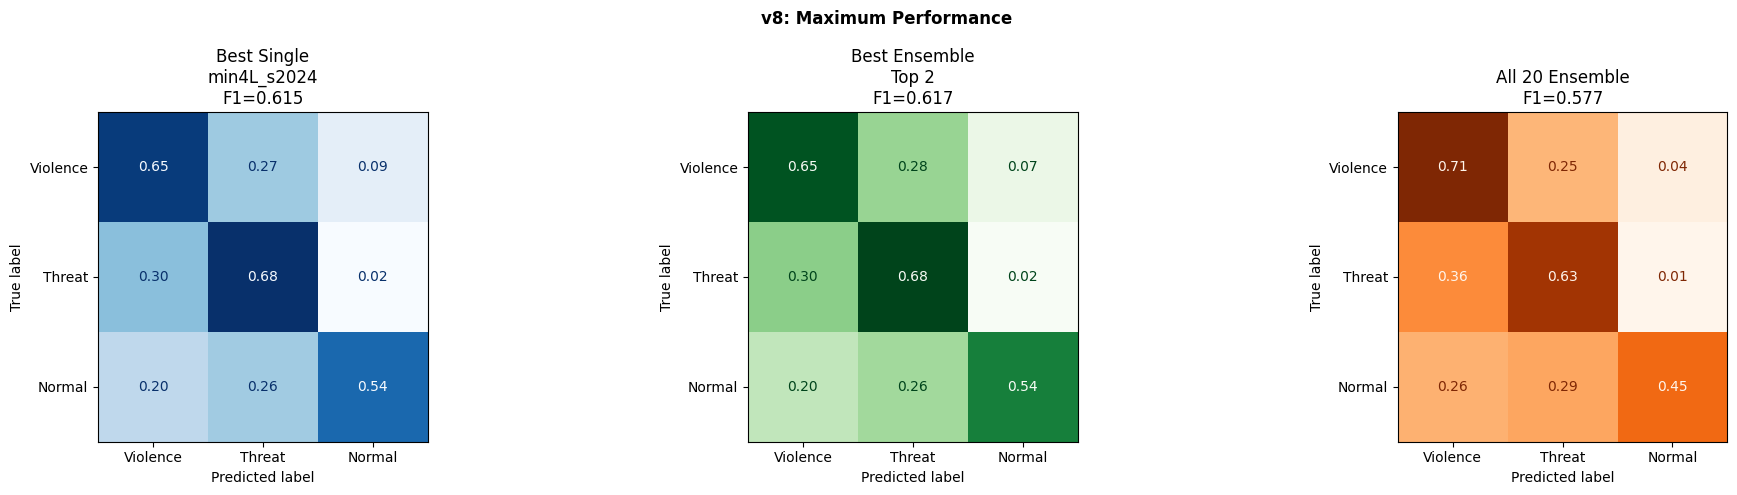


Model F1 stats: mean=0.5731 std=0.0237 min=0.5173 max=0.6146

  🏆 New skeleton best! (0.617 vs v7=0.612)
     Gap to CNN+LSTM: 0.021
  Best single model: 0.615 (seed lottery)


In [5]:
vds=CleanDataset(SKEL_ROOT,'val',TARGET_CLASSES,augment=False,fm=FM,fs=FS)
vld=DataLoader(vds,batch_size=BATCH,shuffle=False,num_workers=0,pin_memory=True)
print(f'Val: {len(vds):,} clips')

# Collect softmax from all models
all_probs={}; all_labels=None
for mi in all_models:
    model=SkelTransformer(FD,nl=mi['nl'],head=mi['head']).to(DEVICE)
    model.load_state_dict(torch.load(mi['path'],map_location=DEVICE)); model.eval()
    pl,ll=[],[]
    with torch.no_grad():
        for c,l in vld:
            pl.append(torch.softmax(model(c.to(DEVICE)),dim=1).cpu().numpy())
            ll.append(l.numpy())
    all_probs[mi['name']]=np.concatenate(pl,axis=0)
    if all_labels is None: all_labels=np.concatenate(ll,axis=0)
    del model; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()

print(f'Predictions from {len(all_probs)} models collected')

# Define ensemble combinations
ranked=[m['name'] for m in all_models]  # already sorted by F1

ensembles={
    'Best single model': ranked[:1],
    'Top 2': ranked[:2],
    'Top 3': ranked[:3],
    'Top 5': ranked[:5],
    'Top 8': ranked[:8],
    'Top 10': ranked[:10],
    'All 20': ranked,
    'All 4L minimal (10)': [m['name'] for m in all_models if m['nl']==4 and m['head']=='minimal'],
    'All 2L minimal (5)': [m['name'] for m in all_models if m['nl']==2],
    'All Config B (5)': [m['name'] for m in all_models if m['head']=='standard'],
    'Mixed: top3 each type': (
        [m['name'] for m in all_models if m['head']=='minimal' and m['nl']==4][:3] +
        [m['name'] for m in all_models if m['nl']==2][:2] +
        [m['name'] for m in all_models if m['head']=='standard'][:2]
    ),
}

# Also: confidence-weighted ensemble (weight by individual F1)
f1_map={m['name']:m['f1'] for m in all_models}

print()
print('='*100)
print('  ENSEMBLE RESULTS (Clean Labels)')
print('='*100)
print(f'  {"Method":<35} {"N":>3} {"F1":>7} {"Acc":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6} {"VioP":>6} {"ThrP":>6}')
print('  '+'-'*88)
print(f'  {"[REF] CNN+LSTM v3":<35} {"1":>3} {"0.638":>7} {"0.668":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6} {"1.00":>6} {"0.39":>6}')
print(f'  {"[REF] v7 best single":<35} {"1":>3} {"0.612":>7} {"0.600":>7} {"0.64":>6} {"0.67":>6} {"0.54":>6} {"0.56":>6} {"0.42":>6}')
print('  '+'-'*88)

best_f1,best_name,best_yt,best_yp=0,'',None,None

for ename, mnames in ensembles.items():
    # Standard average
    avg=np.mean([all_probs[n] for n in mnames],axis=0)
    preds=avg.argmax(axis=1)
    f1=f1_score(all_labels,preds,average='weighted',zero_division=0)
    acc=accuracy_score(all_labels,preds)
    vr=get_m(all_labels,preds,'Violence')
    tr=get_m(all_labels,preds,'Threat')
    nr=get_m(all_labels,preds,'Normal')
    vp=get_m(all_labels,preds,'Violence','precision')
    tp=get_m(all_labels,preds,'Threat','precision')
    mk=''
    if f1>best_f1: best_f1,best_name,best_yt,best_yp=f1,ename,all_labels,preds; mk=' ←'
    print(f'  {ename:<35} {len(mnames):>3} {f1:>7.4f} {acc:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f} {vp:>6.2f} {tp:>6.2f}{mk}')

# F1-weighted ensemble for top combinations
for k in [3,5,10]:
    names=ranked[:k]
    weights_arr=np.array([f1_map[n] for n in names])
    weights_arr=weights_arr/weights_arr.sum()
    wavg=sum(w*all_probs[n] for w,n in zip(weights_arr,names))
    preds=wavg.argmax(axis=1)
    f1=f1_score(all_labels,preds,average='weighted',zero_division=0)
    acc=accuracy_score(all_labels,preds)
    vr=get_m(all_labels,preds,'Violence')
    tr=get_m(all_labels,preds,'Threat')
    nr=get_m(all_labels,preds,'Normal')
    vp=get_m(all_labels,preds,'Violence','precision')
    tp=get_m(all_labels,preds,'Threat','precision')
    mk=''
    if f1>best_f1: best_f1,best_name,best_yt,best_yp=f1,f'F1-weighted top{k}',all_labels,preds; mk=' ←'
    print(f'  {"F1-weighted top"+str(k):<35} {k:>3} {f1:>7.4f} {acc:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f} {vp:>6.2f} {tp:>6.2f}{mk}')

print('  '+'-'*88)
print(f'  Best: {best_name} (F1={best_f1:.4f})')
print('='*100)

# Per-class for best
print(f'\nPer-class — {best_name}:')
print(classification_report(best_yt,best_yp,target_names=TARGET_CLASSES,zero_division=0))

# Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(20,5))
# Best single
bs=all_models[0]
bs_p=all_probs[bs['name']].argmax(1)
cm=confusion_matrix(all_labels,bs_p)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
ConfusionMatrixDisplay(cm_n,display_labels=TARGET_CLASSES).plot(ax=axes[0],colorbar=False,cmap='Blues',values_format='.2f')
axes[0].set_title(f'Best Single\n{bs["name"]}\nF1={bs["f1"]:.3f}')

cm2=confusion_matrix(best_yt,best_yp)
cm2_n=cm2.astype(float)/cm2.sum(axis=1,keepdims=True)
ConfusionMatrixDisplay(cm2_n,display_labels=TARGET_CLASSES).plot(ax=axes[1],colorbar=False,cmap='Greens',values_format='.2f')
axes[1].set_title(f'Best Ensemble\n{best_name}\nF1={best_f1:.3f}')

all_avg=np.mean(list(all_probs.values()),axis=0).argmax(1)
all_f1=f1_score(all_labels,all_avg,average='weighted',zero_division=0)
cm3=confusion_matrix(all_labels,all_avg)
cm3_n=cm3.astype(float)/cm3.sum(axis=1,keepdims=True)
ConfusionMatrixDisplay(cm3_n,display_labels=TARGET_CLASSES).plot(ax=axes[2],colorbar=False,cmap='Oranges',values_format='.2f')
axes[2].set_title(f'All 20 Ensemble\nF1={all_f1:.3f}')
plt.suptitle('v8: Maximum Performance',fontweight='bold')
plt.tight_layout(); plt.show()

# Stats
f1s=[m['f1'] for m in all_models]
print(f'\nModel F1 stats: mean={np.mean(f1s):.4f} std={np.std(f1s):.4f} min={min(f1s):.4f} max={max(f1s):.4f}')

# Final
print()
print('='*70)
cnn=0.638; v7=0.612
if best_f1>cnn:
    print(f'  🏆 SKELETON BEATS CNN+LSTM v3! ({best_f1:.3f} vs {cnn:.3f})')
elif best_f1>v7:
    print(f'  🏆 New skeleton best! ({best_f1:.3f} vs v7={v7:.3f})')
    print(f'     Gap to CNN+LSTM: {cnn-best_f1:.3f}')
else:
    print(f'  📊 {best_f1:.3f} (v7={v7:.3f})')
bs_f1=max(f1s)
if bs_f1>v7:
    print(f'  Best single model: {bs_f1:.3f} (seed lottery)')
print('='*70)


In [4]:
import numpy as np
from pathlib import Path

SAVE_DIR = r'runs/M4B_classifier/TransformerV8'
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
out = Path(SAVE_DIR) / 'feat_stats.npz'

np.savez(str(out), fm=FM, fs=FS)
print(f'Saved: {out}')
print(f'  FM shape: {FM.shape}, FS shape: {FS.shape}')
print(f'  FD: {FD}  (must equal 283)')

Saved: runs\M4B_classifier\TransformerV8\feat_stats.npz
  FM shape: (283,), FS shape: (283,)
  FD: 283  (must equal 283)
